Phillip Vogt   
DSC4310 Machine Learning  
Final Project

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score

Imports. pandas, numpy, matplotlib, seaborn and scikit learn. Metrics used are ROC curve, AUC,
confusion matrix and accuracy.

In [ ]:
RANDOM_STATE = 42
TARGET = "Call_Flag"

DEV_DAYS = ["2014-05-13", "2014-05-14", "2014-05-15",
            "2014-05-16", "2014-05-17", "2014-05-18"]
TEST_DAYS = ["2014-05-19", "2014-05-20"]

VAL_SIZE = 0.25
CONTACT_RATE = 0.10
EQUIVALENCE_MARGIN = 0.005

CATEGORICAL_COLS = ["RTD_ST_CD", "CustomerSegment", "MART_STATUS", "GENDER"]
DROP_COLS = ["DATE_FOR", "EVENT1_30_FLAG"]
ENGINEERED = ["CH4_SHARE_6M", "PAYMENTS_OUTSIDE_CHANNELS_1_TO_5_6M",
              "HAS_LOGIN", "MISSING_6M_VALUES"]

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

Configuration. RANDOM_STATE is passed to every split, cross validation object and model. The six
earliest processing dates are development data, the two latest are test. CONTACT_RATE is the
campaign capacity assumption. EQUIVALENCE_MARGIN is the ROC-AUC difference below which two
candidates are treated as tied.

In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = "/content/drive/MyDrive/ML Summer"
except ImportError:
    DATA_DIR = os.environ.get("DATA_DIR", ".")

DATA_PATH = os.path.join(DATA_DIR, "data.csv")
print("Reading data from:", DATA_PATH)

Mounted at /content/drive
Reading data from: /content/drive/MyDrive/ML Summer/data.csv


Mounts Drive in Colab, otherwise uses DATA_DIR or the current directory.

In [ ]:
def load_data(path):
    frame = pd.read_csv(path)
    frame["DATE_FOR"] = pd.to_datetime(frame["DATE_FOR"])
    return frame


def column_inventory(frame):
    return pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "n_missing": frame.isna().sum(),
        "pct_missing": (frame.isna().mean() * 100).round(2),
        "n_unique": frame.nunique(),})


def daily_summary(frame):
    out = frame.groupby(frame.DATE_FOR.dt.date).agg(
        n_rows=(TARGET, "size"),
        n_calls=(TARGET, "sum"),
        call_rate=(TARGET, "mean"),)
    out["weekday"] = [pd.Timestamp(d).day_name() for d in out.index]
    out["call_rate"] = out["call_rate"].round(4)
    return out[["weekday", "n_rows", "n_calls", "call_rate"]]


def daily_feature_means(frame, columns):
    return frame.groupby(frame.DATE_FOR.dt.date)[columns].mean().round(3)


def call_rate_table(frame, column):
    out = frame.groupby(column)[TARGET].agg(["mean", "size"])
    out.columns = ["call_rate", "n"]
    out["call_rate"] = out["call_rate"].round(4)
    out["times_base_rate"] = (out["call_rate"] / frame[TARGET].mean()).round(2)
    return out

Loading and description functions. call_rate_table returns the call rate within each level of a
variable, as a rate and as a multiple of the base rate.

In [ ]:
def clean(frame):
    out = frame.copy()
    out["MISSING_6M_VALUES"] = out["CHANNEL1_6M"].isna().astype(int)
    six_month_block = ([f"CHANNEL{i}_6M" for i in range(1, 6)]
                       + ["METHOD1_6M", "PAYMENTS_6M", "RECENT_PAYMENT"])
    out[six_month_block] = out[six_month_block].fillna(0)
    return out.drop(columns=[col for col in DROP_COLS if col in out.columns])


def engineer(frame):
    out = frame.copy()
    channel_sum_6m = out[[f"CHANNEL{i}_6M" for i in range(1, 6)]].sum(axis=1)
    has_payments = out["PAYMENTS_6M"] > 0

    out["CH4_SHARE_6M"] = np.where(has_payments,
                                   out["CHANNEL4_6M"] / out["PAYMENTS_6M"].where(has_payments, 1),
                                   0.0)
    out["PAYMENTS_OUTSIDE_CHANNELS_1_TO_5_6M"] = out["PAYMENTS_6M"] - channel_sum_6m
    out["HAS_LOGIN"] = (out["LOGINS"] > 0).astype(int)
    return out


def encode(frame, reference_columns=None):
    out = pd.get_dummies(frame, columns=CATEGORICAL_COLS, drop_first=True).astype(float)
    if reference_columns is not None:
        out = out.reindex(columns=reference_columns, fill_value=0.0)
    return out


def build_features(frame, reference_columns=None):
    return encode(engineer(clean(frame)), reference_columns)

Cleaning and feature functions. clean records the missingness indicator, fills the six month block
with zero, and drops the constant column and the date. engineer builds three features, with both
ratios guarded against a zero denominator. encode applies drop_first and aligns the test set to
the development columns.

In [ ]:
def split_development(X_dev, y_dev):
    return train_test_split(
        X_dev, y_dev, test_size=VAL_SIZE, stratify=y_dev, random_state=RANDOM_STATE)


def check_partitions(X_train, X_val, X_test, y_train, y_val, y_test, n_expected):
    assert len(X_train) + len(X_val) + len(X_test) == n_expected
    assert set(X_train.index).isdisjoint(X_val.index)
    assert set(X_train.index).isdisjoint(X_test.index)
    assert set(X_val.index).isdisjoint(X_test.index)
    assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns)
    assert set(np.unique(y_train)) <= {0, 1}
    assert "EVENT1_30_FLAG" not in X_train.columns
    assert X_train.isna().sum().sum() == 0
    assert X_val.isna().sum().sum() == 0
    assert X_test.isna().sum().sum() == 0
    return True


def partition_summary(y_train, y_val, y_test):
    return pd.DataFrame({
        "n_rows": [len(y_train), len(y_val), len(y_test)],
        "n_calls": [y_train.sum(), y_val.sum(), y_test.sum()],
        "call_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    }, index=["train (05-13 to 05-18)",
              "validation (05-13 to 05-18)",
              "test (05-19 to 05-20)"]).round(4)

Splitting and integrity checks. Divides the development days into training and validation. The
assertions confirm that row counts sum, no row appears in two partitions, columns match across
partitions, the target is binary, the constant column is absent, and no missing values remain.

In [ ]:
def evaluate_probs(probs, y_eval, label, contact_rate=CONTACT_RATE):
    n_contact = int(np.ceil(contact_rate * len(probs)))
    top_indices = np.argsort(-probs, kind="stable")[:n_contact]
    callers_captured = y_eval.iloc[top_indices].sum()
    return pd.Series({
        "model": label,
        "roc_auc": roc_auc_score(y_eval, probs),
        "customers_contacted": n_contact,
        "share_contacted": n_contact / len(probs),
        "callers_captured": int(callers_captured),
        "pct_of_all_callers": callers_captured / y_eval.sum(),})


def evaluate(model, X_eval, y_eval, label, contact_rate=CONTACT_RATE):
    return evaluate_probs(model.predict_proba(X_eval)[:, 1], y_eval, label, contact_rate)


def threshold_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return pd.Series({
        "customers_contacted": int(tp + fp),
        "share_of_book": (tp + fp) / len(y_true),
        "callers_captured": int(tp),
        "recall_sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "false_positive_rate": fp / (fp + tn),
        "call_rate_among_contacted": tp / (tp + fp),
        "accuracy": accuracy_score(y_true, y_pred),})


def contact_table(probs, y_eval, contact_rates=(0.05, 0.10, 0.15, 0.20)):
    order = np.argsort(-probs, kind="stable")
    total_callers = y_eval.sum()
    rows = []
    for rate in contact_rates:
        n_contact = int(np.ceil(rate * len(y_eval)))
        callers_captured = y_eval.iloc[order[:n_contact]].sum()
        rows.append({
            "contact_rate": f"{rate:.0%}",
            "customers_contacted": n_contact,
            "callers_captured": int(callers_captured),
            "pct_of_all_callers": callers_captured / total_callers,
            "call_rate_among_contacted": callers_captured / n_contact,})
    return pd.DataFrame(rows).round(4)

Evaluation functions. evaluate_probs selects exactly the top share by stable argsort.
contact_table takes cached probabilities. threshold_metrics returns recall, specificity, false
positive rate, precision and accuracy from the confusion matrix. call_rate_among_contacted is
precision, TP divided by TP plus FP.

In [ ]:
def tune(estimator, grid, X_train, y_train, folds=5):
    search = GridSearchCV(
        estimator,
        grid,
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,)
    search.fit(X_train, y_train)
    print("Best parameters:", search.best_params_)
    print(f"Cross-validated ROC-AUC: {search.best_score_:.4f}")
    return search

Grid search helper, scored on ROC-AUC with stratified 5 fold cross validation on the training
data.

In [ ]:
raw = load_data(DATA_PATH)

print(f"Rows:    {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]}")
print(f"Date range: {raw.DATE_FOR.min().date()} to {raw.DATE_FOR.max().date()}")
print(f"Overall call rate: {raw[TARGET].mean():.4f}  ({raw[TARGET].sum():,} calls)")
raw.head()

Rows:    130,086
Columns: 29
Date range: 2014-05-13 to 2014-05-20
Overall call rate: 0.0366  (4,764 calls)


,DATE_FOR,RTD_ST_CD,CustomerSegment,Tenure,Age,MART_STATUS,GENDER,CHANNEL1_6M,CHANNEL2_6M,CHANNEL3_6M,...,CHANNEL5_3M,METHOD1_3M,PAYMENTS_3M,NOT_DI_3M,NOT_DI_6M,EVENT1_30_FLAG,EVENT2_90_SUM,LOGINS,POLICYPURCHASECHANNEL,Call_Flag
0,2014-05-19,ST_S0,1,16.175222,78.403833,MS_S0,F,0.0,0.0,1.0,...,2,0,3,0,0,0,0,0,0,0
1,2014-05-17,ST_S0,1,15.931554,70.989733,MS_S1,F,0.0,6.0,0.0,...,0,3,3,0,0,0,0,0,0,0
2,2014-05-15,ST_S0,1,15.937029,87.578371,MS_S2,M,0.0,0.0,10.0,...,0,0,6,0,0,0,0,0,0,0
3,2014-05-16,ST_S1,1,15.934292,68.438056,MS_S2,M,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,1,0
4,2014-05-20,ST_S0,1,15.501711,80.514716,MS_S0,F,0.0,0.0,1.0,...,0,0,1,0,0,0,0,0,0,0


130,086 policyholder day records across eight processing dates in May 2014. Overall call rate
3.66%.

In [ ]:
column_inventory(raw)

,dtype,n_missing,pct_missing,n_unique
DATE_FOR,datetime64[ns],0,0.00,8
RTD_ST_CD,object,0,0.00,51
CustomerSegment,object,0,0.00,4
Tenure,float64,0,0.00,10228
Age,float64,0,0.00,22347
MART_STATUS,object,0,0.00,5
GENDER,object,0,0.00,2
CHANNEL1_6M,float64,809,0.62,13
CHANNEL2_6M,float64,809,0.62,17
CHANNEL3_6M,float64,809,0.62,14


Column inventory. Eight columns share an identical block of 809 missing values. RTD_ST_CD has 51
levels. EVENT1_30_FLAG has one unique value.

In [ ]:
constant_cols = [col for col in raw.columns if raw[col].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols)
print(f"Unique values in EVENT1_30_FLAG: {raw['EVENT1_30_FLAG'].unique()}")
print()
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")

Constant columns: ['EVENT1_30_FLAG']
Unique values in EVENT1_30_FLAG: [0]

Exact duplicate rows: 278


EVENT1_30_FLAG is zero for every record. 278 rows are exact duplicates across all 29 columns. Both
are dropped. The data contains no customer identifier.

In [ ]:
six_month_cols = ([f"CHANNEL{i}_6M" for i in range(1, 6)]
                   + ["METHOD1_6M", "PAYMENTS_6M", "RECENT_PAYMENT"])
missing_matrix = raw[six_month_cols].isna()
is_missing_6m = raw["CHANNEL1_6M"].isna()

print("Columns with missing values:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print()
print(f"Rows missing ALL 6-month columns:  {missing_matrix.all(axis=1).sum():,}")
print(f"Rows missing SOME but not all:     "
      f"{(missing_matrix.any(axis=1) & ~missing_matrix.all(axis=1)).sum():,}")
print()
print(f"Call rate, rows missing 6M values: {raw.loc[is_missing_6m, TARGET].mean():.4f}")
print(f"Call rate, all other rows:         {raw.loc[~is_missing_6m, TARGET].mean():.4f}")

Columns with missing values:
CHANNEL1_6M       809
CHANNEL2_6M       809
CHANNEL3_6M       809
CHANNEL4_6M       809
CHANNEL5_6M       809
METHOD1_6M        809
RECENT_PAYMENT    809
PAYMENTS_6M       809
dtype: int64

Rows missing ALL 6-month columns:  809
Rows missing SOME but not all:     0

Call rate, rows missing 6M values: 0.0482
Call rate, all other rows:         0.0365


All 809 rows with missing values are missing all eight six month columns at once, and none is
missing only some. Those rows call at 4.82% against 3.65% elsewhere. They are filled with zero and
flagged.

In [ ]:
tenure_check = pd.DataFrame({
    "rows_missing_6M": [
        raw.loc[is_missing_6m, "Tenure"].median(),
        raw.loc[is_missing_6m, "Tenure"].max(),
        (raw.loc[is_missing_6m, "Tenure"] < 1).mean(),
    ],
    "all_other_rows": [
        raw.loc[~is_missing_6m, "Tenure"].median(),
        raw.loc[~is_missing_6m, "Tenure"].max(),
        (raw.loc[~is_missing_6m, "Tenure"] < 1).mean(),
    ],
}, index=["median_tenure_years", "max_tenure_years", "share_under_1_year"]).round(3)
tenure_check

,rows_missing_6M,all_other_rows
median_tenure_years,5.281,7.006
max_tenure_years,42.010,63.091
share_under_1_year,0.114,0.079


Tenure among the rows with missing values. Median 5.3 years, maximum above 40 years, 11.4% below
one year.

In [ ]:
daily = daily_summary(raw)
daily

,weekday,n_rows,n_calls,call_rate
DATE_FOR,,,,
2014-05-13,Tuesday,15254,641,0.0420
2014-05-14,Wednesday,16884,648,0.0384
2014-05-15,Thursday,16624,638,0.0384
2014-05-16,Friday,16570,665,0.0401
2014-05-17,Saturday,16053,622,0.0387
2014-05-18,Sunday,17002,635,0.0373
2014-05-19,Monday,16704,533,0.0319
2014-05-20,Tuesday,14995,382,0.0255


Call rate by processing date. The six earliest days range from 3.74% to 4.18%. The last two are
3.17% and 2.54%. May 13 and May 20 are both Tuesdays.

In [ ]:
drift_cols = ["CHANNEL4_6M", "LOGINS", "PAYMENTS_6M", "Age", "Tenure"]
feature_drift = daily_feature_means(raw, drift_cols)
feature_drift

,CHANNEL4_6M,LOGINS,PAYMENTS_6M,Age,Tenure
DATE_FOR,,,,,
2014-05-13,0.393,0.920,4.867,48.886,8.672
2014-05-14,0.374,0.910,4.872,49.515,8.891
2014-05-15,0.397,0.926,4.830,48.680,8.479
2014-05-16,0.423,0.972,4.796,48.424,8.373
2014-05-17,0.411,0.989,4.856,48.561,8.480
2014-05-18,0.387,0.949,4.854,49.058,8.660
2014-05-19,0.411,0.965,4.843,48.979,8.682
2014-05-20,0.415,0.957,4.872,48.586,8.407


Feature means by processing date. All are flat across the eight days.

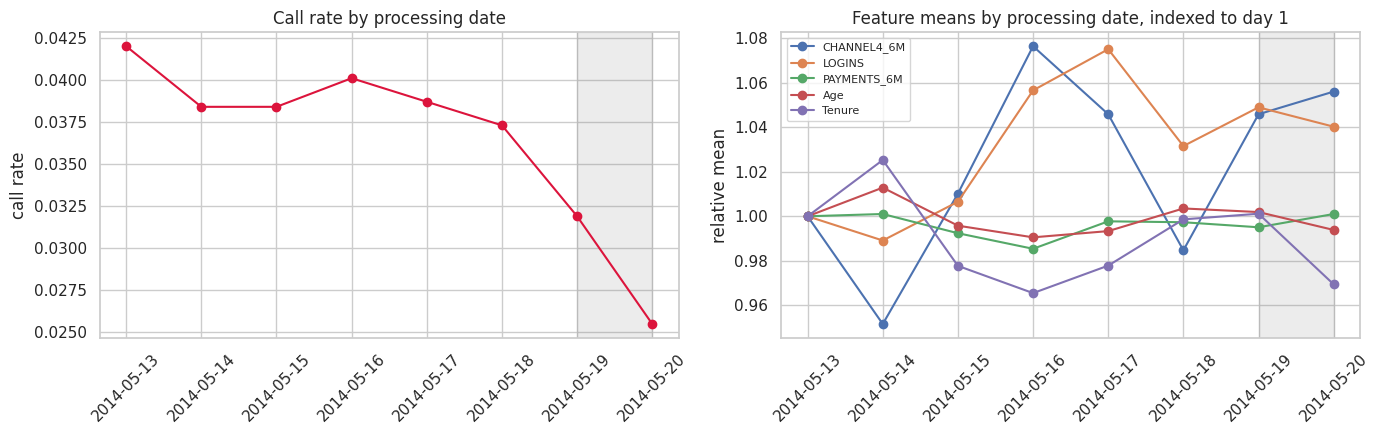

In [ ]:
fig, axes= plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(daily.index, daily["call_rate"], marker="o", color="crimson")
axes[0].axvspan(pd.Timestamp(TEST_DAYS[0]).date(), pd.Timestamp(TEST_DAYS[-1]).date(),
                alpha=0.15, color="grey")
axes[0].set_title("Call rate by processing date")
axes[0].set_ylabel("call rate")
axes[0].tick_params(axis="x", rotation=45)

normalised = feature_drift / feature_drift.iloc[0]
for col in normalised.columns:
    axes[1].plot(normalised.index, normalised[col], marker="o", label=col)
axes[1].axvspan(pd.Timestamp(TEST_DAYS[0]).date(), pd.Timestamp(TEST_DAYS[-1]).date(),
                alpha=0.15, color="grey")
axes[1].set_title("Feature means by processing date, indexed to day 1")
axes[1].set_ylabel("relative mean")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The call rate falls in the final two days while the input features stay flat. Neither the brief
nor the data dictionary states that the outcome window is incomplete for those dates, so they are
used as the test set.

In [ ]:
raw_dev= raw[raw.DATE_FOR.dt.strftime("%Y-%m-%d").isin(DEV_DAYS)]
raw_test =raw[raw.DATE_FOR.dt.strftime("%Y-%m-%d").isin(TEST_DAYS)]

print(f"Development days {DEV_DAYS[0]} to {DEV_DAYS[-1]}: "
      f"{len(raw_dev):,} rows, call rate {raw_dev[TARGET].mean():.4f}")
print(f"Test days        {TEST_DAYS[0]} to {TEST_DAYS[-1]}: "
      f"{len(raw_test):,} rows, call rate {raw_test[TARGET].mean():.4f}")
#print()
print(f"Every row assigned exactly once: {len(raw_dev) + len(raw_test) == len(raw)}")

Development days 2014-05-13 to 2014-05-18: 98,387 rows, call rate 0.0391
Test days        2014-05-19 to 2014-05-20: 31,699 rows, call rate 0.0289
Every row assigned exactly once: True


Splits by processing date. Development is May 13 to May 18, test is May 19 and May 20.

In [ ]:
identity_pairs = raw.groupby(["Age", "Tenure"])["DATE_FOR"].nunique()

print(f"Records:                                {len(raw):,}")
print(f"Distinct age and tenure pairs:          {len(identity_pairs):,}")
print(f"Pairs appearing on more than one date:  {(identity_pairs > 1).sum():,}")

Records:                                130,086
Distinct age and tenure pairs:          129,486
Pairs appearing on more than one date:  84


Age and tenure are both fractional, so an exact match on the pair is a rough stand in for a customer identifier. Almost every record has its own pair and very few pairs appear on more than one date, which suggests the test dates hold different policyholders from the development dates.

In [ ]:
df = raw_dev.copy()
print(f"EDA population: {len(df):,} rows, {df[TARGET].sum():,} calls, "
      f"{df[TARGET].mean():.4f} base rate")

EDA population: 98,387 rows, 3,849 calls, 0.0391 base rate


Sets the exploration population to the development days.

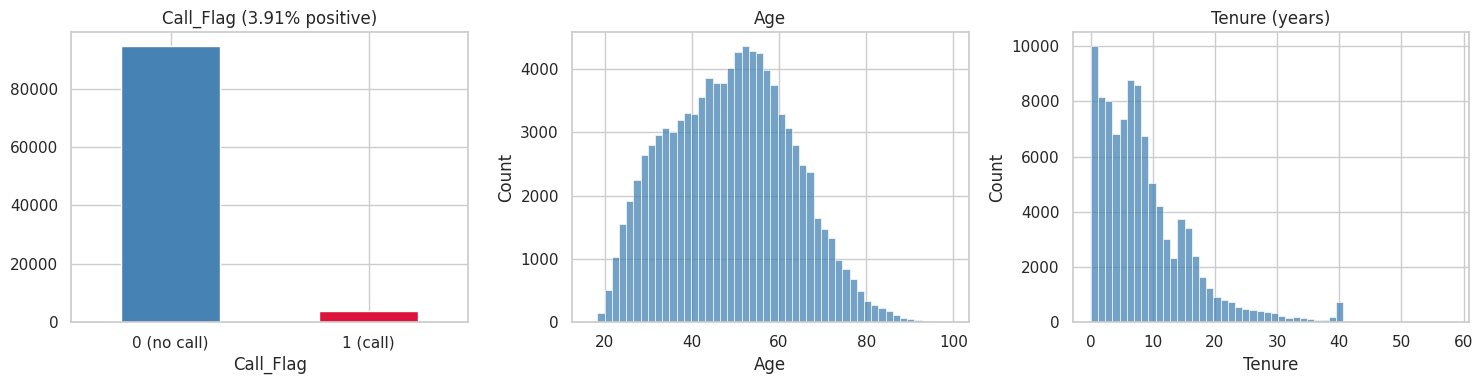

A model predicting 'no call' for every customer would be 96.09% accurate.


In [ ]:
fig, axes =plt.subplots(1, 3, figsize=(15, 4))

df[TARGET].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "crimson"])
axes[0].set_title(f"Call_Flag ({df[TARGET].mean():.2%} positive)")
axes[0].set_xticklabels(["0 (no call)", "1 (call)"], rotation=0)

sns.histplot(df["Age"], bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Age")

sns.histplot(df["Tenure"], bins=50, ax=axes[2], color="steelblue")
axes[2].set_title("Tenure (years)")

plt.tight_layout()
plt.show()

print(f"A model predicting 'no call' for every customer would be "
      f"{1 - df[TARGET].mean():.2%} accurate.")

The target is 3.89% positive. Predicting no call for every customer scores 96.11% accuracy. Age is
roughly normal around 49 years. Tenure is right skewed.

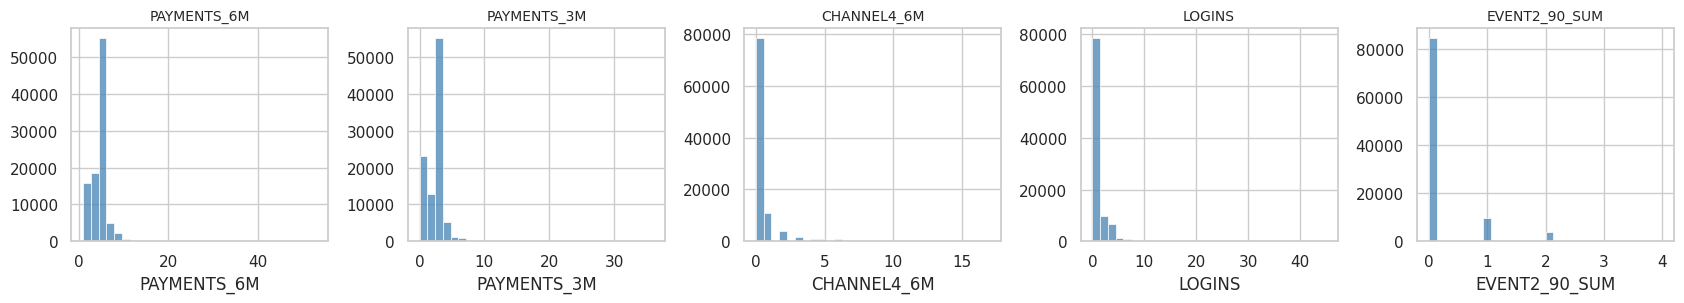

,count,mean,std,min,25%,50%,75%,max
PAYMENTS_6M,97769.0,4.85,2.04,1.0,4.0,6.0,6.0,53.0
PAYMENTS_3M,98387.0,2.41,1.24,0.0,2.0,3.0,3.0,36.0
CHANNEL4_6M,97769.0,0.40,1.06,0.0,0.0,0.0,0.0,17.0
LOGINS,98387.0,0.94,2.14,0.0,0.0,0.0,1.0,45.0
EVENT2_90_SUM,98387.0,0.19,0.50,0.0,0.0,0.0,0.0,4.0


In [ ]:
count_cols =["PAYMENTS_6M", "PAYMENTS_3M", "CHANNEL4_6M", "LOGINS", "EVENT2_90_SUM"]

fig, axes= plt.subplots(1, len(count_cols), figsize=(17, 3.2))
for ax, col in zip(axes, count_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

df[count_cols].describe().T.round(2)

Payment and activity counts are right skewed with long tails. Values are left untransformed.

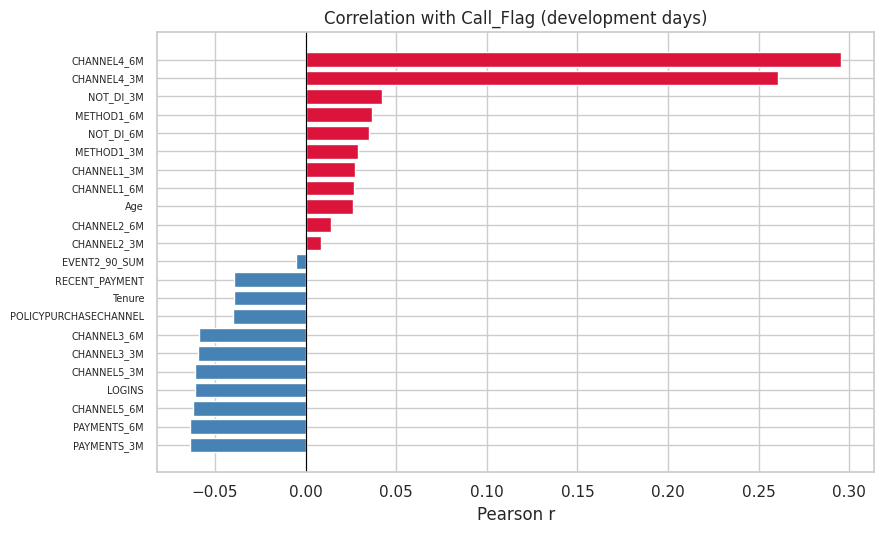

,corr_with_target
PAYMENTS_3M,-0.0639
PAYMENTS_6M,-0.0636
CHANNEL5_6M,-0.0621
LOGINS,-0.0611
CHANNEL5_3M,-0.0608
CHANNEL3_3M,-0.0596
CHANNEL3_6M,-0.0589
POLICYPURCHASECHANNEL,-0.0399
Tenure,-0.0397
RECENT_PAYMENT,-0.0393


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop([TARGET, "EVENT1_30_FLAG"])
correlations=df[numeric_cols].corrwith(df[TARGET]).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(correlations.index,
        correlations.values,
        color=["crimson" if v > 0 else "steelblue" for v in correlations.values])
ax.axvline(0, color="black", linewidth=0.8)
ax.tick_params(axis="y", labelsize=7)
ax.set_title("Correlation with Call_Flag (development days)")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()

correlations.round(4).to_frame("corr_with_target")

CHANNEL4_6M and CHANNEL4_3M are the strongest predictors by roughly four times. Everything else is
below 0.07 in absolute value. The dictionary does not state which channel is which.

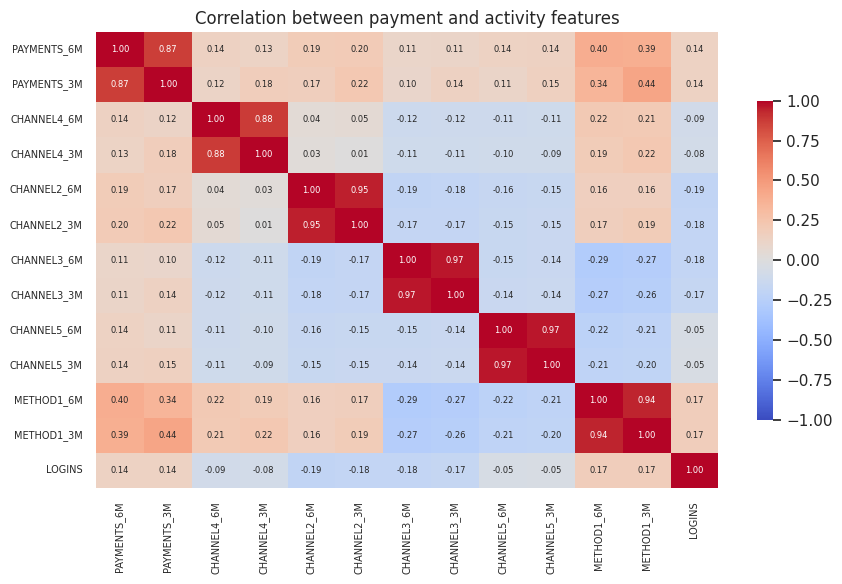

Most strongly inter-correlated feature pairs:
                         correlation
feature_a   feature_b               
CHANNEL5_6M CHANNEL5_3M        0.966
CHANNEL3_6M CHANNEL3_3M        0.965
CHANNEL2_6M CHANNEL2_3M        0.950
METHOD1_6M  METHOD1_3M         0.944
CHANNEL4_6M CHANNEL4_3M        0.878
PAYMENTS_6M PAYMENTS_3M        0.869
PAYMENTS_3M METHOD1_3M         0.438
PAYMENTS_6M METHOD1_6M         0.398


In [ ]:
payment_activity = ["PAYMENTS_6M", "PAYMENTS_3M", "CHANNEL4_6M", "CHANNEL4_3M",
                    "CHANNEL2_6M", "CHANNEL2_3M", "CHANNEL3_6M", "CHANNEL3_3M",
                    "CHANNEL5_6M", "CHANNEL5_3M", "METHOD1_6M", "METHOD1_3M", "LOGINS"]

feature_correlations = df[payment_activity].corr()

fig, ax=plt.subplots(figsize=(9, 6))
sns.heatmap(feature_correlations, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.tick_params(labelsize=7)
ax.set_title("Correlation between payment and activity features")
plt.tight_layout()
plt.show()

upper =feature_correlations.where(
    np.triu(np.ones(feature_correlations.shape), k=1).astype(bool))
strong_pairs = (upper.stack()
                     .sort_values(key=abs, ascending=False)
                     .head(8)
                     .to_frame("correlation")
                     .round(3))
strong_pairs.index.names = ["feature_a", "feature_b"]
print("Most strongly inter-correlated feature pairs:")
print(strong_pairs)

Correlation between features. Each three month column correlates above 0.87 with its six month
counterpart, and PAYMENTS_6M includes the channel counts. All columns are retained.

In [ ]:
for column in ["CustomerSegment", "GENDER", "MART_STATUS", "NOT_DI_3M",
               "NOT_DI_6M", "RECENT_PAYMENT", "POLICYPURCHASECHANNEL"]:
    print(f"--- {column} ---")
    print(call_rate_table(df, column))
    print()

print("--- LOGINS > 0 ---")
print(call_rate_table(df.assign(HAS_LOGIN=(df["LOGINS"] > 0)), "HAS_LOGIN"))

--- CustomerSegment ---
                 call_rate      n  times_base_rate
CustomerSegment                                   
1                   0.0359  72622             0.92
2                   0.0495  19122             1.27
3                   0.0538   3812             1.38
NONE                0.0318   2831             0.81

--- GENDER ---
        call_rate      n  times_base_rate
GENDER                                   
F          0.0372  45352             0.95
M          0.0408  53035             1.04

--- MART_STATUS ---
             call_rate      n  times_base_rate
MART_STATUS                                   
MS_S0           0.0531   3655             1.36
MS_S1           0.0412  34502             1.05
MS_S2           0.0344  44070             0.88
MS_S3           0.0438  10146             1.12
MS_S4           0.0456   6014             1.17

--- NOT_DI_3M ---
           call_rate      n  times_base_rate
NOT_DI_3M                                   
0             0.0372  93059

Call rates within each category. Customers with at least one login call at roughly a quarter of
the rate of those with none. NOT_DI_3M and NOT_DI_6M follow the dictionary wording, meaning the
customer had been enrolled in automated payments.

In [ ]:
print("Cross-tabulation of the two automated-payment flags:")
print(pd.crosstab(df["NOT_DI_3M"], df["NOT_DI_6M"]))
print()
print(f"Rows with 3M=1 but 6M=0: {((df.NOT_DI_3M == 1) & (df.NOT_DI_6M == 0)).sum()}")
print(f"Rows with 6M=1 but 3M=0: {((df.NOT_DI_6M == 1) & (df.NOT_DI_3M == 0)).sum()}")

Cross-tabulation of the two automated-payment flags:
NOT_DI_6M      0     1
NOT_DI_3M             
0          90820  2239
1              0  5328

Rows with 3M=1 but 6M=0: 0
Rows with 6M=1 but 3M=0: 2239


The two automated payment flags nest. Every row flagged for three months is also flagged for six
months, and none is flagged for three but not six.

In [ ]:
channel_6m=[f"CHANNEL{i}_6M" for i in range(1, 6)]
channel_3m=[f"CHANNEL{i}_3M" for i in range(1, 6)]

sum_6m = df[channel_6m].sum(axis=1)
sum_3m = df[channel_3m].sum(axis=1)

channel_reconciliation = pd.DataFrame({
    "sum_differs_from_total": [(sum_6m != df.PAYMENTS_6M).mean(),
                               (sum_3m != df.PAYMENTS_3M).mean()],
    "sum_exceeds_total": [(sum_6m > df.PAYMENTS_6M).mean(),
                          (sum_3m > df.PAYMENTS_3M).mean()],
    "sum_falls_short_of_total": [(sum_6m < df.PAYMENTS_6M).mean(),
                                 (sum_3m < df.PAYMENTS_3M).mean()],}, index=["6M", "3M"]).round(4)
channel_reconciliation

,sum_differs_from_total,sum_exceeds_total,sum_falls_short_of_total
6M,0.4642,0.0,0.4579
3M,0.3888,0.0,0.3888


The five channel counts differ from the payment totals in 46% of six month rows and 39% of three
month rows. They never exceed the total.

In [ ]:
outside_6m = df["PAYMENTS_6M"] - sum_6m
outside_3m = df["PAYMENTS_3M"] - sum_3m

print(f"Correlation with target, 6M payments outside channels 1-5: "
      f"{outside_6m.corr(df[TARGET]):.4f}")
print(f"Correlation with target, 3M payments outside channels 1-5: "
      f"{outside_3m.corr(df[TARGET]):.4f}")
print()
print(call_rate_table(df.assign(PAYS_OUTSIDE=(outside_6m > 0)), "PAYS_OUTSIDE"))

Correlation with target, 6M payments outside channels 1-5: -0.1150
Correlation with target, 3M payments outside channels 1-5: -0.1115

              call_rate      n  times_base_rate
PAYS_OUTSIDE                                   
False            0.0560  53335             1.43
True             0.0192  45052             0.49


Payments outside Channels 1 to 5 correlate negatively with the target at 0.115 in magnitude. Those
customers call at 1.92% against 5.60%.

In [ ]:
dev_clean=raw_dev.drop_duplicates()
test_clean=raw_test.drop_duplicates()
n_dropped=(len(raw_dev) - len(dev_clean)) + (len(raw_test) - len(test_clean))

dev_encoded = build_features(dev_clean)
FEATURE_COLUMNS = [col for col in dev_encoded.columns if col != TARGET]
test_encoded = build_features(test_clean, reference_columns=dev_encoded.columns)

print(f"Duplicate rows removed: {n_dropped:,}")
print(f"Development matrix: {dev_encoded.shape[0]:,} rows x {len(FEATURE_COLUMNS)} predictors")
print(f"Test matrix:        {test_encoded.shape[0]:,} rows x "
      f"{test_encoded.shape[1] - 1} predictors")
print()
print(f"Columns identical across partitions: "
      f"{list(dev_encoded.columns) == list(test_encoded.columns)}")
print(f"Missing values remaining: {dev_encoded.isna().sum().sum() + test_encoded.isna().sum().sum()}")

Duplicate rows removed: 278
Development matrix: 98,153 rows x 84 predictors
Test matrix:        31,655 rows x 84 predictors

Columns identical across partitions: True
Missing values remaining: 0


Applies the cleaning and feature pipeline. Duplicates are removed before splitting. The test
matrix is built against the development columns.

In [ ]:
CONSTRUCTED = ["CH4_SHARE_6M", "PAYMENTS_OUTSIDE_CHANNELS_1_TO_5_6M", "HAS_LOGIN"]
RAW_FEATURES=[col for col in FEATURE_COLUMNS if col not in CONSTRUCTED]

print(f"Engineered feature set: {len(FEATURE_COLUMNS)} columns")
print(f"Raw feature set:        {len(RAW_FEATURES)} columns "
      f"(drops {', '.join(CONSTRUCTED)})")
print()
dev_encoded[ENGINEERED].describe().T.round(3)

Engineered feature set: 84 columns
Raw feature set:        81 columns (drops CH4_SHARE_6M, PAYMENTS_OUTSIDE_CHANNELS_1_TO_5_6M, HAS_LOGIN)



,count,mean,std,min,25%,50%,75%,max
CH4_SHARE_6M,98153.0,0.090,0.228,0.0,0.0,0.0,0.0,1.0
PAYMENTS_OUTSIDE_CHANNELS_1_TO_5_6M,98153.0,1.841,2.493,0.0,0.0,0.0,4.0,31.0
HAS_LOGIN,98153.0,0.412,0.492,0.0,0.0,0.0,1.0,1.0
MISSING_6M_VALUES,98153.0,0.006,0.079,0.0,0.0,0.0,0.0,1.0


Two candidate feature sets. The engineered set is all 84 columns. The raw set drops the three
constructed features and retains MISSING_6M_VALUES.

In [ ]:
X_dev = dev_encoded[FEATURE_COLUMNS]
y_dev = dev_encoded[TARGET].astype(int)
X_test = test_encoded[FEATURE_COLUMNS]
y_test = test_encoded[TARGET].astype(int)

X_train, X_val, y_train, y_val = split_development(X_dev, y_dev)
check_partitions(X_train, X_val, X_test, y_train, y_val, y_test,
                 len(dev_encoded) + len(test_encoded))

print(partition_summary(y_train, y_val, y_test))

                             n_rows  n_calls  call_rate
train (05-13 to 05-18)        73614     2861     0.0389
validation (05-13 to 05-18)   24539      954     0.0389
test (05-19 to 05-20)         31655      910     0.0287


Training and validation are a stratified 75/25 split of the development days. Test is the two
later days. Development call rate 3.89%, test call rate 2.87%.

In [ ]:
results = []

Collects one row of validation results per model.

In [ ]:
logistic_grid = {"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]}

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),])

logistic_search = tune(logistic_pipeline, logistic_grid, X_train, y_train)
logistic_model = logistic_search.best_estimator_

results.append(evaluate(logistic_model, X_val, y_val, "Logistic Regression"))
print()
print(results[-1])

Best parameters: {'clf__C': 0.001}
Cross-validated ROC-AUC: 0.8605

model                  Logistic Regression
roc_auc                           0.853343
customers_contacted                   2454
share_contacted                   0.100004
callers_captured                       514
pct_of_all_callers                0.538784
dtype: object


Logistic regression with the scaler inside the pipeline. C controls the inverse strength of L2
regularisation.

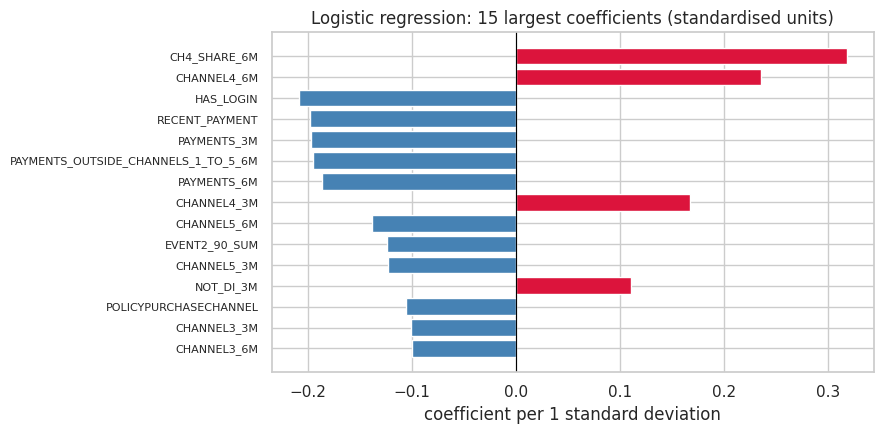

,coefficient,odds_ratio_per_1_sd
CH4_SHARE_6M,0.317,1.374
CHANNEL4_6M,0.235,1.266
HAS_LOGIN,-0.209,0.812
RECENT_PAYMENT,-0.198,0.820
PAYMENTS_3M,-0.197,0.821
PAYMENTS_OUTSIDE_CHANNELS_1_TO_5_6M,-0.196,0.822
PAYMENTS_6M,-0.186,0.830
CHANNEL4_3M,0.167,1.181
CHANNEL5_6M,-0.138,0.871
EVENT2_90_SUM,-0.125,0.883


In [ ]:
coefficients = pd.Series(
    logistic_model.named_steps["clf"].coef_[0], index=X_train.columns
).sort_values(key=abs, ascending=False)

top_coefficients = coefficients.head(15)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top_coefficients.index[::-1],
        top_coefficients.values[::-1],
        color=["crimson" if v > 0 else "steelblue" for v in top_coefficients.values][::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.tick_params(axis="y", labelsize=8)
ax.set_title("Logistic regression: 15 largest coefficients (standardised units)")
ax.set_xlabel("coefficient per 1 standard deviation")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "coefficient": top_coefficients,
    "odds_ratio_per_1_sd": np.exp(top_coefficients),}).round(3)

Largest coefficients. Inputs are standardised, so each odds ratio describes a one standard
deviation increase.

In [ ]:
tree_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [50, 100, 250],
    "criterion": ["gini", "entropy"],}

tree_search = tune(DecisionTreeClassifier(random_state=RANDOM_STATE),
                   tree_grid, X_train, y_train)
tree_model = tree_search.best_estimator_

results.append(evaluate(tree_model, X_val, y_val, "Decision Tree"))
#print()
print(results[-1])

KeyboardInterrupt: 

Decision tree tuned on max_depth, min_samples_leaf and criterion.

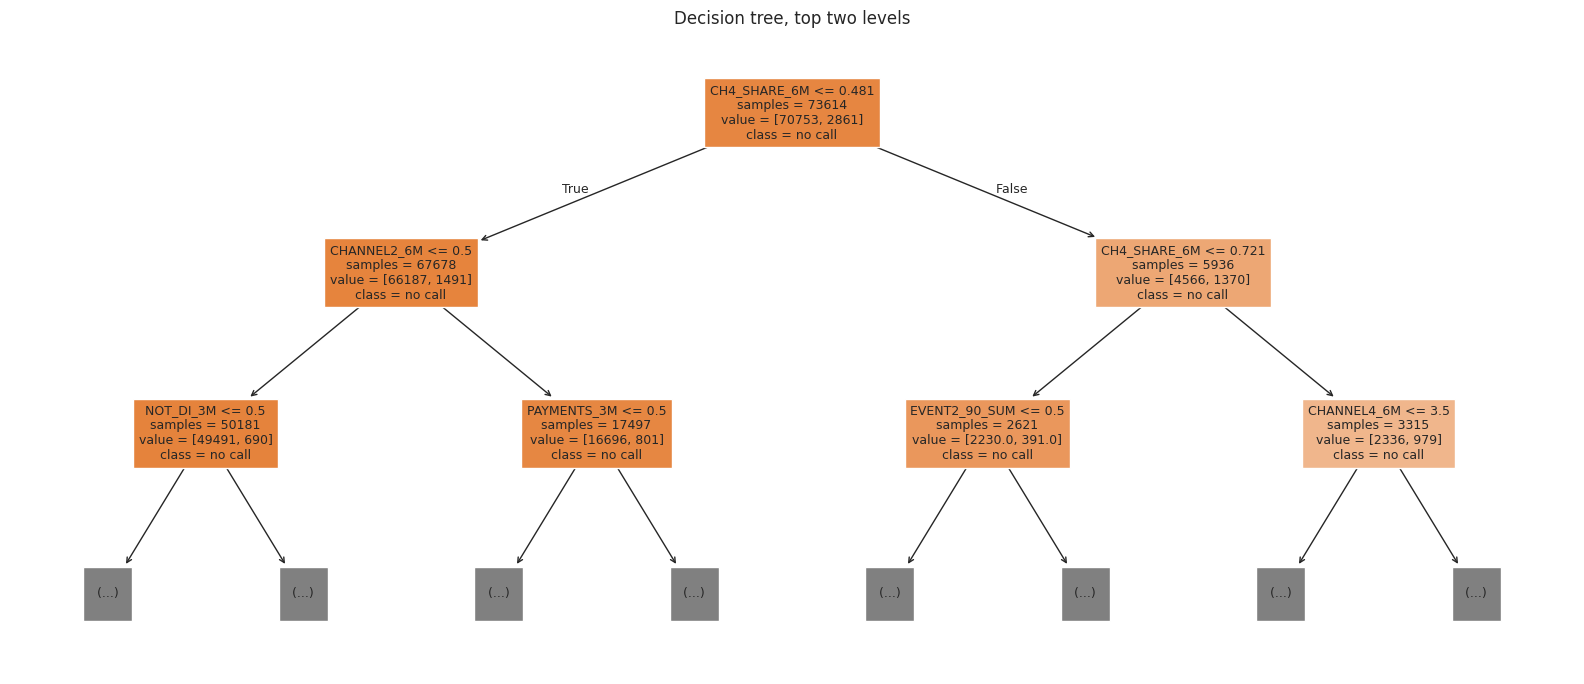

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    tree_model,
    max_depth=2,
    feature_names=list(X_train.columns),
    class_names=["no call", "call"],
    filled=True,
    impurity=False,
    fontsize=9,
    ax=ax,)
ax.set_title("Decision tree, top two levels")
plt.tight_layout()
plt.show()

Top two levels of the fitted tree. The root split is on CH4_SHARE_6M.

In [ ]:
forest_grid = {
    "max_depth": [10, 15, None],
    "min_samples_leaf": [25, 50],}
forest_defaults = {"n_estimators": 200, "max_features": "sqrt"}

print("--- Random Forest on the ENGINEERED feature set ---")
engineered_search = tune(
    RandomForestClassifier(**forest_defaults, random_state=RANDOM_STATE, n_jobs=1),
    forest_grid, X_train, y_train)
engineered_model = engineered_search.best_estimator_
engineered_model.set_params(n_jobs=-1)

print()
print("--- Random Forest on the RAW feature set ---")
raw_search = tune(
    RandomForestClassifier(**forest_defaults, random_state=RANDOM_STATE, n_jobs=1),
    forest_grid, X_train[RAW_FEATURES], y_train)
raw_model = raw_search.best_estimator_
raw_model.set_params(n_jobs=-1)

--- Random Forest on the ENGINEERED feature set ---
Best parameters: {'max_depth': 15, 'min_samples_leaf': 25}
Cross-validated ROC-AUC: 0.8694

--- Random Forest on the RAW feature set ---
Best parameters: {'max_depth': None, 'min_samples_leaf': 25}
Cross-validated ROC-AUC: 0.8682


RandomForestClassifier(min_samples_leaf=25, n_estimators=200, n_jobs=-1,
                       random_state=42)

Random forest tuned on max_depth and min_samples_leaf over six combinations. n_estimators is fixed
at 200 and max_features at sqrt. Tuned once per candidate feature set.

In [ ]:
feature_set_comparison = pd.DataFrame([
    evaluate(engineered_model, X_val, y_val, "Random Forest, engineered features"),
    evaluate(raw_model, X_val[RAW_FEATURES], y_val, "Random Forest, raw features"),]).set_index("model")

print(feature_set_comparison.round(4))
print()

engineered_auc = feature_set_comparison.loc["Random Forest, engineered features", "roc_auc"]
raw_auc = feature_set_comparison.loc["Random Forest, raw features", "roc_auc"]
difference = engineered_auc - raw_auc
equivalent = abs(difference) < EQUIVALENCE_MARGIN

print(f"Validation ROC-AUC, engineered: {engineered_auc:.4f}")
print(f"Validation ROC-AUC, raw:        {raw_auc:.4f}")
print(f"Difference:                     {difference:+.4f}")
print(f"Equivalence margin:             {EQUIVALENCE_MARGIN:.4f}")
print(f"Specifications indistinguishable: {equivalent}")
print()

if equivalent or raw_auc > engineered_auc:
    SELECTED_FEATURES = RAW_FEATURES
    forest_model, forest_search, FEATURE_SET_NAME = raw_model, raw_search, "raw"
    reason = ("the two are within the equivalence margin, so the simpler specification is "
              "selected on parsimony") if equivalent else "it scored higher"
else:
    SELECTED_FEATURES = FEATURE_COLUMNS
    forest_model, forest_search, FEATURE_SET_NAME = engineered_model, engineered_search, "engineered"
    reason = "it scored higher by more than the equivalence margin"

forest_params = dict(forest_search.best_params_)
print(f"Selected feature set: {FEATURE_SET_NAME} ({len(SELECTED_FEATURES)} columns)")
print(f"Reason: {reason}")
print(f"Selected hyperparameters: {forest_params}")

results.append(evaluate(forest_model, X_val[SELECTED_FEATURES], y_val, "Random Forest"))
print()
print(results[-1])

                                    roc_auc  customers_contacted  \
model                                                              
Random Forest, engineered features   0.8634                 2454   
Random Forest, raw features          0.8642                 2454   

                                    share_contacted  callers_captured  \
model                                                                   
Random Forest, engineered features              0.1               523   
Random Forest, raw features                     0.1               519   

                                    pct_of_all_callers  
model                                                   
Random Forest, engineered features              0.5482  
Random Forest, raw features                     0.5440  

Validation ROC-AUC, engineered: 0.8634
Validation ROC-AUC, raw:        0.8642
Difference:                     -0.0009
Equivalence margin:             0.0050
Specifications indistinguishable: True

Selected

Feature set selection. The two specifications differ by less than the equivalence margin, and the
smaller set is selected.

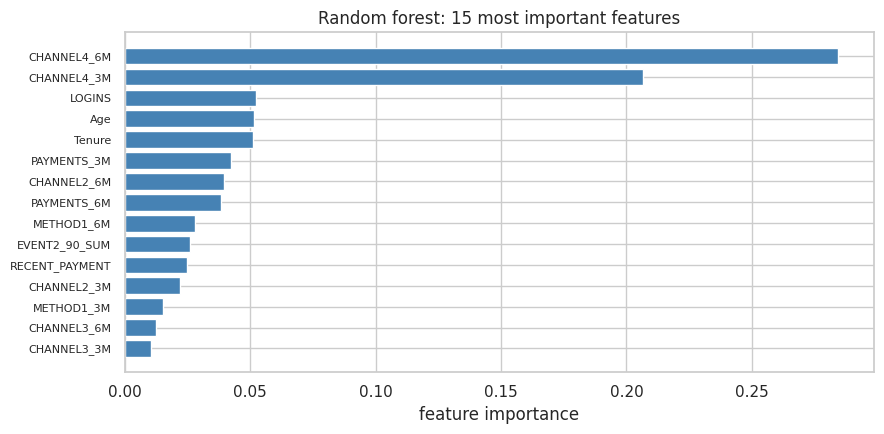

,importance
CHANNEL4_6M,0.2845
CHANNEL4_3M,0.2065
LOGINS,0.0522
Age,0.0517
Tenure,0.0513
PAYMENTS_3M,0.0424
CHANNEL2_6M,0.0395
PAYMENTS_6M,0.0385
METHOD1_6M,0.0281
EVENT2_90_SUM,0.0262


In [ ]:
importances = pd.Series(
    forest_model.feature_importances_, index=SELECTED_FEATURES).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(importances.index[::-1], importances.values[::-1], color="steelblue")
ax.tick_params(axis="y", labelsize=8)
ax.set_title("Random forest: 15 most important features")
ax.set_xlabel("feature importance")
plt.tight_layout()
plt.show()

importances.round(4).to_frame("importance")

Feature importances. The three Channel 4 features lead, followed by payment activity.

In [ ]:
majority_index = y_train.index[y_train == 0]
minority_index = y_train.index[y_train == 1]

oversampled_minority = minority_index.to_series().sample(
    n=len(majority_index), replace=True, random_state=RANDOM_STATE).values
undersampled_majority = majority_index.to_series().sample(
    n=len(minority_index), replace=False, random_state=RANDOM_STATE).values

resampling_schemes = {
    "No resampling": y_train.index.values,
    "Random over-sampling": np.concatenate([majority_index.values, oversampled_minority]),
    "Random under-sampling": np.concatenate([undersampled_majority, minority_index.values]),}

imbalance_rows = []
for label, index in resampling_schemes.items():
    model = RandomForestClassifier(
        **forest_defaults, **forest_params, random_state=RANDOM_STATE, n_jobs=-1
    ).fit(X_train.loc[index, SELECTED_FEATURES], y_train.loc[index])
    row = evaluate(model, X_val[SELECTED_FEATURES], y_val, label)
    row["training_rows"] = len(index)
    row["training_call_rate"] = y_train.loc[index].mean()
    row["mean_predicted_probability"] = model.predict_proba(
        X_val[SELECTED_FEATURES])[:, 1].mean()
    imbalance_rows.append(row)

imbalance_comparison = pd.DataFrame(imbalance_rows).set_index("model")
print(imbalance_comparison[["training_rows", "training_call_rate", "roc_auc",
                            "pct_of_all_callers", "mean_predicted_probability"]].round(4))
print()
print(f"Actual validation call rate: {y_val.mean():.4f}")

                       training_rows  training_call_rate  roc_auc  \
model                                                               
No resampling                  73614              0.0389   0.8642   
Random over-sampling          141506              0.5000   0.8649   
Random under-sampling           5722              0.5000   0.8615   

                       pct_of_all_callers  mean_predicted_probability  
model                                                                  
No resampling                      0.5440                      0.0388  
Random over-sampling               0.5535                      0.2574  
Random under-sampling              0.5262                      0.3480  

Actual validation call rate: 0.0389


Class imbalance comparison against random over sampling and random under sampling, applied to
training rows only. Over sampling produces 141,506 training rows and under sampling 5,722. Mean
predicted probability is 0.0388 unresampled against 0.26 and 0.35 balanced, with a true rate of
0.0389.

In [ ]:
comparison = pd.DataFrame(results).set_index("model")
comparison.round(4)

,roc_auc,customers_contacted,share_contacted,callers_captured,pct_of_all_callers
model,,,,,
Logistic Regression,0.8533,2454,0.1,514,0.5388
Decision Tree,0.8433,2454,0.1,502,0.5262
Random Forest,0.8642,2454,0.1,519,0.5440


Validation results for all three models on identical rows. Logistic regression and the tree use
the engineered feature set, the forest uses the raw set.

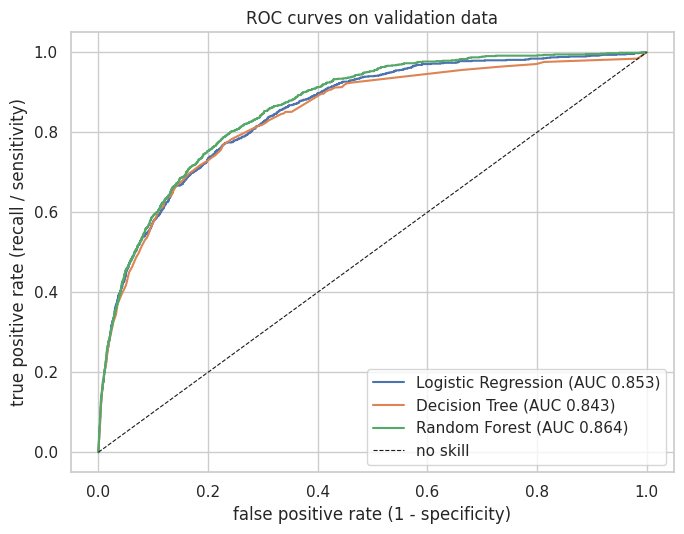

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for model, cols, label in [(logistic_model, FEATURE_COLUMNS, "Logistic Regression"),
                           (tree_model, FEATURE_COLUMNS, "Decision Tree"),
                           (forest_model, SELECTED_FEATURES, "Random Forest")]:
    probs = model.predict_proba(X_val[cols])[:, 1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    ax.plot(fpr, tpr, label=f"{label} (AUC {roc_auc_score(y_val, probs):.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="no skill")
ax.set_xlabel("false positive rate (1 - specificity)")
ax.set_ylabel("true positive rate (recall / sensitivity)")
ax.set_title("ROC curves on validation data")
ax.legend()
plt.tight_layout()
plt.show()

ROC curves. The vertical axis is the true positive rate, also called recall or sensitivity. The
horizontal axis is the false positive rate, one minus specificity.

In [ ]:
def ablate(columns, label):
    model = RandomForestClassifier(
        **forest_defaults, **forest_params, random_state=RANDOM_STATE, n_jobs=-1
    ).fit(X_train[columns], y_train)
    return evaluate(model, X_val[columns], y_val, label)


all_features = list(X_train.columns)
channel4_cols = [col for col in all_features if "CHANNEL4" in col or col == "CH4_SHARE_6M"]
login_cols = [col for col in all_features if col in ("LOGINS", "HAS_LOGIN")]

ablation = pd.DataFrame([
    ablate(all_features, "Full feature set"),
    ablate([col for col in all_features if col not in channel4_cols],
           "Without any Channel 4 feature"),
    ablate([col for col in all_features if col not in login_cols],
           "Without LOGINS / HAS_LOGIN"),
    ablate(RAW_FEATURES, "Without constructed features"),
    ablate(channel4_cols, "Channel 4 features only"),]).set_index("model")

ablation.round(4)

,roc_auc,customers_contacted,share_contacted,callers_captured,pct_of_all_callers
model,,,,,
Full feature set,0.8627,2454,0.1,521,0.5461
Without any Channel 4 feature,0.8513,2454,0.1,496,0.5199
Without LOGINS / HAS_LOGIN,0.8621,2454,0.1,522,0.5472
Without constructed features,0.8642,2454,0.1,519,0.5440
Channel 4 features only,0.7578,2454,0.1,500,0.5241


Ablation. The forest is refitted on feature subsets with hyperparameters held fixed, each
contacting exactly the top 10% by rank.

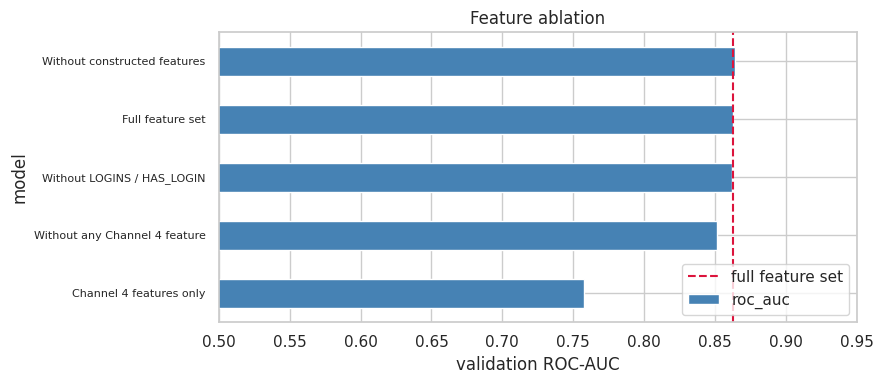

In [ ]:
fig, ax=plt.subplots(figsize=(9, 4))
ablation["roc_auc"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(ablation.loc["Full feature set", "roc_auc"], color="crimson",
           linestyle="--", label="full feature set")
ax.set_xlim(0.5, 0.95)
ax.set_xlabel("validation ROC-AUC")
ax.set_title("Feature ablation")
ax.tick_params(axis="y", labelsize=8)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The ablation results as a chart.

In [ ]:
probs_val=forest_model.predict_proba(X_val[SELECTED_FEATURES])[:, 1]
validation_contact=contact_table(probs_val, y_val)
print(validation_contact.to_string(index=False))

contact_rate  customers_contacted  callers_captured  pct_of_all_callers  call_rate_among_contacted
          5%                 1227               363              0.3805                     0.2958
         10%                 2454               519              0.5440                     0.2115
         15%                 3681               614              0.6436                     0.1668
         20%                 4908               689              0.7222                     0.1404


Campaign outcomes at four contact budgets on validation data, selecting exactly the highest
scoring share by rank position. call_rate_among_contacted is precision, pct_of_all_callers is
recall.

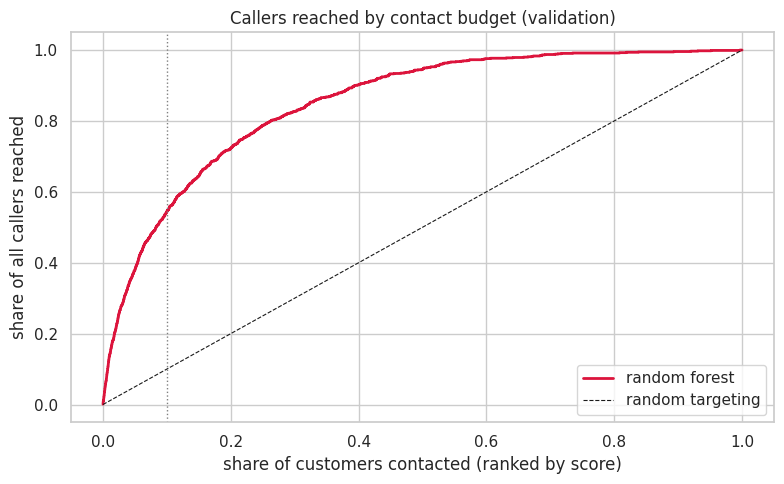

In [ ]:
labels_sorted= y_val.values[np.argsort(-probs_val, kind="stable")]

cumulative=np.cumsum(labels_sorted) / labels_sorted.sum()
population_share= np.arange(1, len(labels_sorted) + 1) / len(labels_sorted)

fig, ax= plt.subplots(figsize=(8, 5))
ax.plot(population_share, cumulative, color="crimson", linewidth=2, label="random forest")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random targeting")
ax.axvline(CONTACT_RATE, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("share of customers contacted (ranked by score)")
ax.set_ylabel("share of all callers reached")
ax.set_title("Callers reached by contact budget (validation)")
ax.legend()
plt.tight_layout()
plt.show()

Cumulative share of callers reached by contact budget. The dotted line marks 10%.

In [ ]:
SCORE_THRESHOLD = float(np.quantile(probs_val, 1 - CONTACT_RATE))
FINAL_MODEL = forest_model
FINAL_MODEL_NAME = "Random Forest"

validation_frozen = evaluate_probs(probs_val, y_val, FINAL_MODEL_NAME)

print("Frozen before any test data is scored:")
print(f"  model:                  {FINAL_MODEL_NAME}")
print(f"  feature set:            {FEATURE_SET_NAME} ({len(SELECTED_FEATURES)} columns)")
print(f"  hyperparameters:        {forest_params}")
print(f"  contact rate:           {CONTACT_RATE:.0%}")
print(f"  score threshold:        {SCORE_THRESHOLD:.6f}")
print()
print("Validation performance at exactly the top 10% ranking:")
print(f"  customers contacted:    {int(validation_frozen['customers_contacted']):,} "
      f"({validation_frozen['share_contacted']:.2%})")
print(f"  callers captured:       {int(validation_frozen['callers_captured']):,} "
      f"({validation_frozen['pct_of_all_callers']:.2%} of all callers)")

Frozen before any test data is scored:
  model:                  Random Forest
  feature set:            raw (81 columns)
  hyperparameters:        {'max_depth': None, 'min_samples_leaf': 25}
  contact rate:           10%
  score threshold:        0.098746

Validation performance at exactly the top 10% ranking:
  customers contacted:    2,454 (10.00%)
  callers captured:       519 (54.40% of all callers)


Freezes the model, feature set, contact rate and threshold. The threshold is the validation score
at the 90th percentile.

In [ ]:
test_probs = FINAL_MODEL.predict_proba(X_test[SELECTED_FEATURES])[:, 1]
test_roc = roc_auc_score(y_test, test_probs)

print(f"Model: {FINAL_MODEL_NAME}")
print(f"Test period: {TEST_DAYS[0]} to {TEST_DAYS[-1]}")
print(f"Test rows: {len(y_test):,}   Test callers: {y_test.sum():,}   "
      f"Base rate: {y_test.mean():.4f}")
print()
print(f"{'':12s}{'validation':>13s}{'test':>13s}")
print(f"{'ROC-AUC':12s}{comparison.loc[FINAL_MODEL_NAME, 'roc_auc']:13.4f}{test_roc:13.4f}")

Model: Random Forest
Test period: 2014-05-19 to 2014-05-20
Test rows: 31,655   Test callers: 910   Base rate: 0.0287

               validation         test
ROC-AUC            0.8642       0.8510


Scores the test set once. test_probs is cached here and reused by every table and chart below.

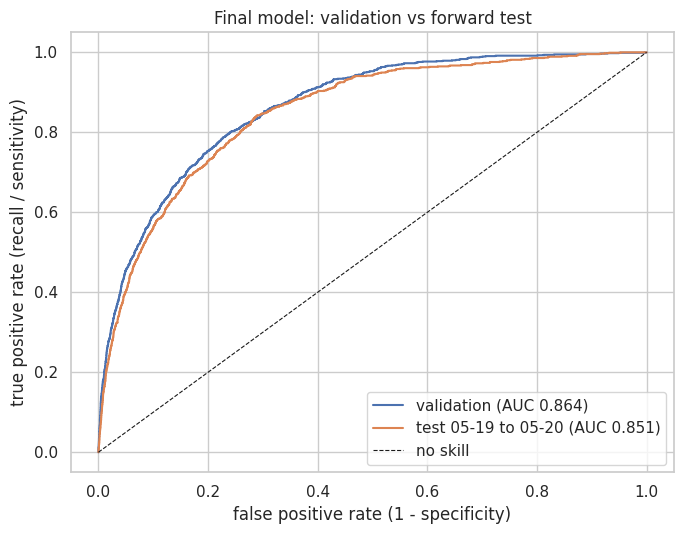

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
fpr_val, tpr_val, _ = roc_curve(y_val, probs_val)
fpr_test, tpr_test, _ = roc_curve(y_test, test_probs)

ax.plot(fpr_val, tpr_val, label=f"validation (AUC {comparison.loc[FINAL_MODEL_NAME, 'roc_auc']:.3f})")
ax.plot(fpr_test, tpr_test, label=f"test 05-19 to 05-20 (AUC {test_roc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="no skill")
ax.set_xlabel("false positive rate (1 - specificity)")
ax.set_ylabel("true positive rate (recall / sensitivity)")
ax.set_title("Final model: validation vs forward test")
ax.legend()
plt.tight_layout()
plt.show()

Validation and test ROC curves for the final model.

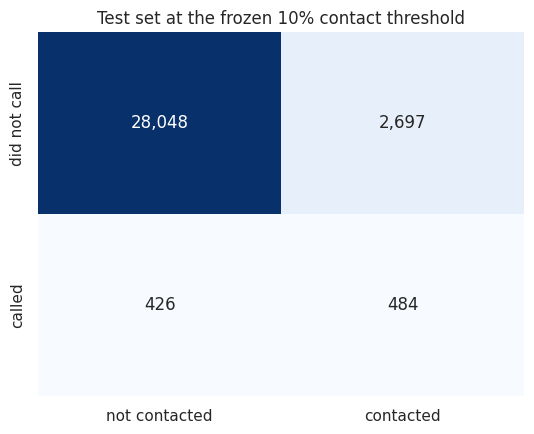

customers_contacted          3181.0000
share_of_book                   0.1005
callers_captured              484.0000
recall_sensitivity              0.5319
specificity                     0.9123
false_positive_rate             0.0877
call_rate_among_contacted       0.1522
accuracy                        0.9013
dtype: float64


In [ ]:
test_predictions = (test_probs >= SCORE_THRESHOLD).astype(int)
matrix = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(matrix, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["not contacted", "contacted"],
            yticklabels=["did not call", "called"], ax=ax)
ax.set_title(f"Test set at the frozen {CONTACT_RATE:.0%} contact threshold")
plt.tight_layout()
plt.show()

print(threshold_metrics(y_test, test_predictions).round(4))

Confusion matrix and the metrics derived from it at the frozen threshold. Recall is the share of
actual callers contacted, specificity the share of non callers not contacted.

In [ ]:
test_contact = contact_table(test_probs, y_test)
print(test_contact.to_string(index=False))

contact_rate  customers_contacted  callers_captured  pct_of_all_callers  call_rate_among_contacted
          5%                 1583               329              0.3615                     0.2078
         10%                 3166               484              0.5319                     0.1529
         15%                 4749               577              0.6341                     0.1215
         20%                 6331               645              0.7088                     0.1019


Campaign outcomes across contact budgets on the test days, computed from the cached probabilities.

In [ ]:
naive_rule = (X_test["CHANNEL4_6M"] > 0).astype(int)
rule_volume = int(naive_rule.sum())
rule_reach = y_test[naive_rule == 1].sum() / y_test.sum()

order = np.argsort(-test_probs, kind="stable")
matched_reach = y_test.values[order[:rule_volume]].sum() / y_test.sum()
budget_volume = int(np.ceil(CONTACT_RATE * len(y_test)))
budget_reach = y_test.values[order[:budget_volume]].sum() / y_test.sum()

baseline_comparison = pd.DataFrame({
    "approach": [
        "Rule: contact everyone with CHANNEL4_6M > 0",
        f"{FINAL_MODEL_NAME}, matched contact volume",
        f"{FINAL_MODEL_NAME}, frozen {CONTACT_RATE:.0%} budget",
    ],
    "customers_contacted": [rule_volume, rule_volume, budget_volume],
    "share_of_book": [naive_rule.mean(), naive_rule.mean(), CONTACT_RATE],
    "pct_of_all_callers_reached": [rule_reach, matched_reach, budget_reach],}).round(4)

print(baseline_comparison.to_string(index=False))

                                   approach  customers_contacted  share_of_book  pct_of_all_callers_reached
Rule: contact everyone with CHANNEL4_6M > 0                 6534         0.2064                      0.6341
      Random Forest, matched contact volume                 6534         0.2064                      0.7154
           Random Forest, frozen 10% budget                 3166         0.1000                      0.5319


The model against a rule contacting everyone with any Channel 4 payment history, compared at
matched contact volume.

In [ ]:
final_metrics = threshold_metrics(y_test, test_predictions)

verification = pd.DataFrame({
    "item": [
        "Rows loaded",
        "Constant column removed",
        "Exact duplicate rows removed",
        "Rows with shared missing-value block",
        "Missing-value treatment",
        "Missing values remaining",
        "Predictors after encoding",
        "Development dates",
        "Test dates",
        "Train rows / call rate",
        "Validation rows / call rate",
        "Test rows / call rate",
        "Selected feature set",
        "Selected model",
        "Selected hyperparameters",
        "Cross-validated training ROC-AUC",
        "Validation ROC-AUC",
        "Validation contact % (exact top 10%)",
        "Validation callers captured",
        "Frozen validation score threshold",
        "Test ROC-AUC",
        "Test contact % from frozen threshold",
        "Test customers contacted",
        "Test callers captured",
        "Test callers captured (%)",
        "Test call rate among contacted",
        "Test recall (sensitivity)",
        "Test specificity",
        "Test probabilities generated",
    ],
    "value": [
        f"{len(raw):,}",
        "EVENT1_30_FLAG (all zeros)",
        f"{n_dropped:,}",
        f"{int(is_missing_6m.sum()):,} (all 8 columns together)",
        "filled with 0 plus MISSING_6M_VALUES indicator",
        f"{int(dev_encoded.isna().sum().sum() + test_encoded.isna().sum().sum())}",
        f"{len(SELECTED_FEATURES)} used of {len(FEATURE_COLUMNS)} available",
        f"{DEV_DAYS[0]} to {DEV_DAYS[-1]}",
        f"{TEST_DAYS[0]} to {TEST_DAYS[-1]}",
        f"{len(y_train):,} / {y_train.mean():.4f}",
        f"{len(y_val):,} / {y_val.mean():.4f}",
        f"{len(y_test):,} / {y_test.mean():.4f}",
        FEATURE_SET_NAME,
        FINAL_MODEL_NAME,
        str({**forest_defaults, **forest_params}),
        f"{forest_search.best_score_:.4f}",
        f"{validation_frozen['roc_auc']:.4f}",
        f"{validation_frozen['share_contacted']:.4%} "
        f"({int(validation_frozen['customers_contacted']):,} customers)",
        f"{int(validation_frozen['callers_captured']):,} "
        f"({validation_frozen['pct_of_all_callers']:.4f} of all callers)",
        f"{SCORE_THRESHOLD:.6f}",
        f"{test_roc:.4f}",
        f"{final_metrics['share_of_book']:.4%}",
        f"{int(final_metrics['customers_contacted']):,}",
        f"{int(final_metrics['callers_captured']):,}",
        f"{final_metrics['recall_sensitivity']:.4f}",
        f"{final_metrics['call_rate_among_contacted']:.4f}",
        f"{final_metrics['recall_sensitivity']:.4f}",
        f"{final_metrics['specificity']:.4f}",
        "once, cached as test_probs and reused throughout",],})
print(verification.to_string(index=False))

                                item                                                                                    value
                         Rows loaded                                                                                  130,086
             Constant column removed                                                               EVENT1_30_FLAG (all zeros)
        Exact duplicate rows removed                                                                                      278
Rows with shared missing-value block                                                             809 (all 8 columns together)
             Missing-value treatment                                           filled with 0 plus MISSING_6M_VALUES indicator
            Missing values remaining                                                                                        0
           Predictors after encoding                                                                  81 used of 84 av

Verification table from rows loaded to final outcome. Validation contacts exactly 10% by rank
position. The test percentage is what the frozen threshold produced.

In [ ]:
import sklearn

print("Random seed:      ", RANDOM_STATE)
print("pandas:           ", pd.__version__)
print("numpy:            ", np.__version__)
print("scikit-learn:     ", sklearn.__version__)
print("seaborn:          ", sns.__version__)
print()
print("Development days: ", f"{DEV_DAYS[0]} to {DEV_DAYS[-1]}")
print("Test days:        ", f"{TEST_DAYS[0]} to {TEST_DAYS[-1]}")
print("Selected model:   ", FINAL_MODEL_NAME)
print("Hyperparameters:  ", {**forest_defaults, **forest_params})
print("Contact rate:     ", f"{CONTACT_RATE:.0%}")
print("Score threshold:  ", round(SCORE_THRESHOLD, 4))

Random seed:       42
pandas:            2.2.2
numpy:             2.0.2
scikit-learn:      1.6.1
seaborn:           0.13.2

Development days:  2014-05-13 to 2014-05-18
Test days:         2014-05-19 to 2014-05-20
Selected model:    Random Forest
Hyperparameters:   {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_leaf': 25}
Contact rate:      10%
Score threshold:   0.0987
